## Data Loading



In [131]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

Read Dataset


In [132]:
df = pd.read_csv("StudentsPerformance.csv")

In [133]:
df.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


##DATA CLEANING

In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [135]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [136]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [137]:
df.duplicated().sum()

np.int64(0)

In [138]:
df.drop_duplicates(inplace=True)

In [139]:
df.shape

(1000, 8)

In [140]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [141]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## Exploratory Data Analysis (EDA)

 Univariate Analysis

<Axes: xlabel='parental level of education', ylabel='count'>

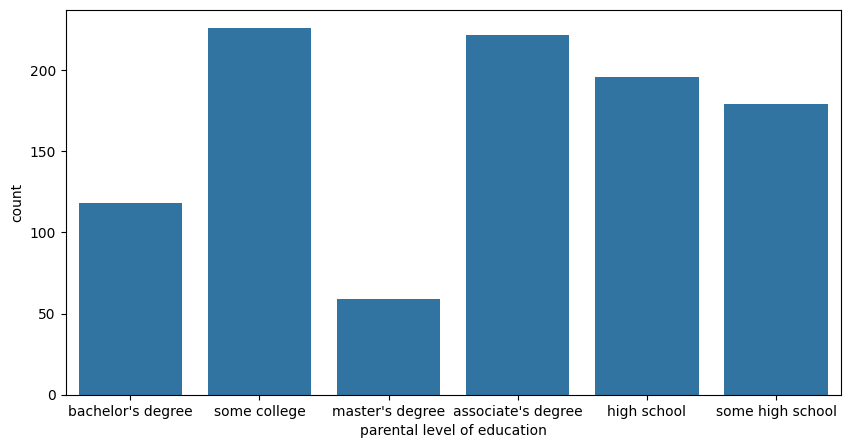

In [142]:
plt.figure(figsize=(10, 5))
sns.countplot(x="parental level of education", data=df)

<Axes: xlabel='race/ethnicity', ylabel='count'>

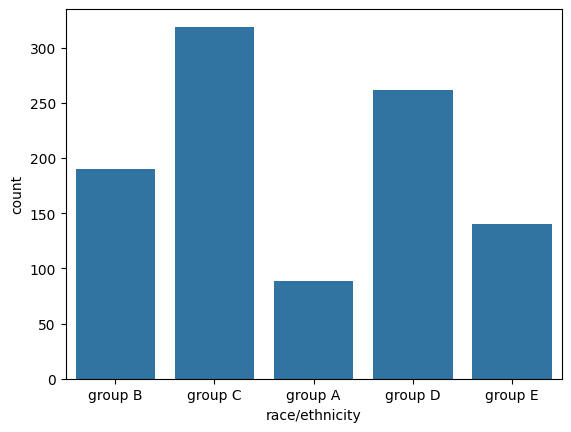

In [143]:
sns.countplot(x="race/ethnicity", data=df)

<Axes: xlabel='gender', ylabel='count'>

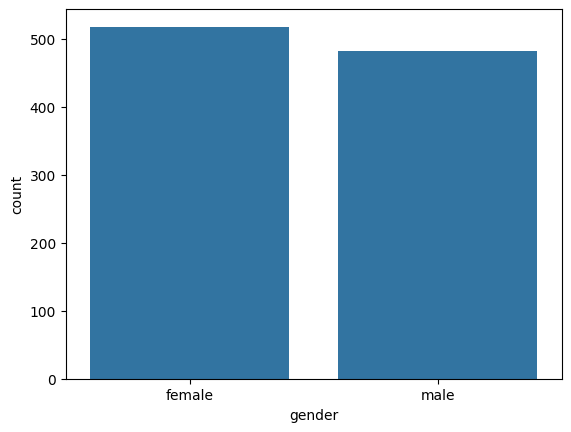

In [144]:
sns.countplot(x="gender", data=df)



<Axes: xlabel='lunch', ylabel='count'>

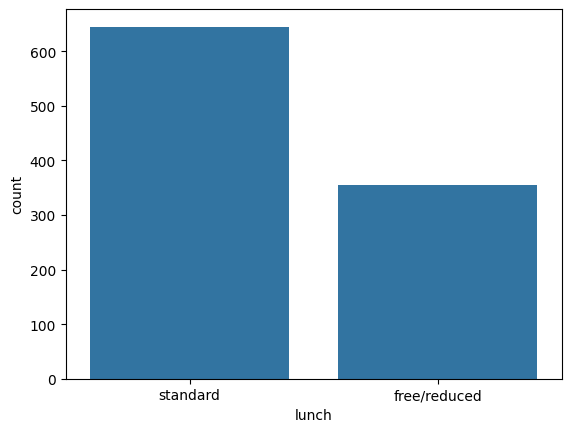

In [145]:
sns.countplot(x="lunch", data=df)

<Axes: xlabel='test preparation course', ylabel='count'>

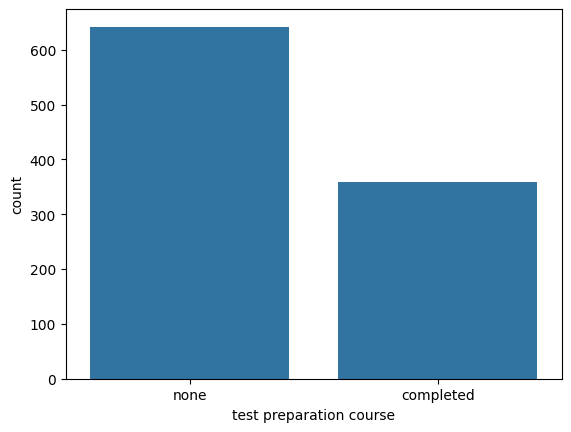

In [146]:
sns.countplot(x="test preparation course", data=df)

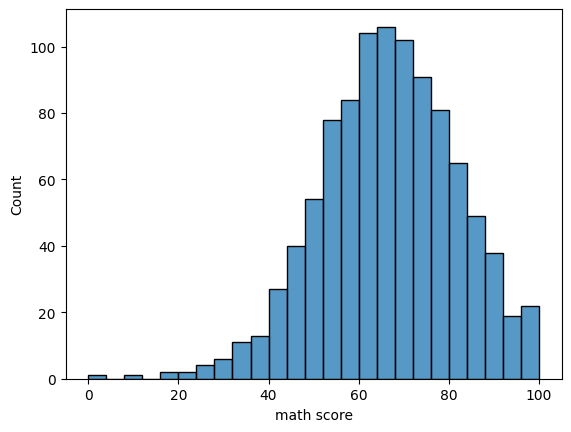

In [147]:
sns.histplot(df["math score"])

plt.show()

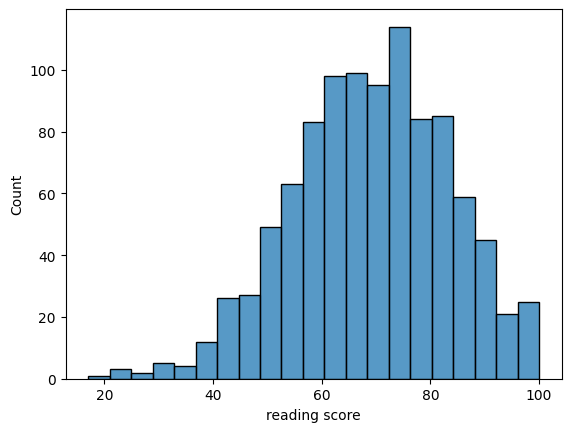

In [148]:
sns.histplot(df["reading score"])

plt.show()

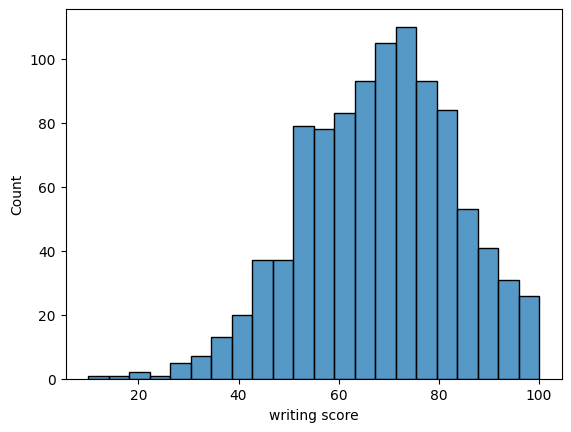

In [149]:
sns.histplot(df["writing score"])

plt.show()

### Bivariate Analysis

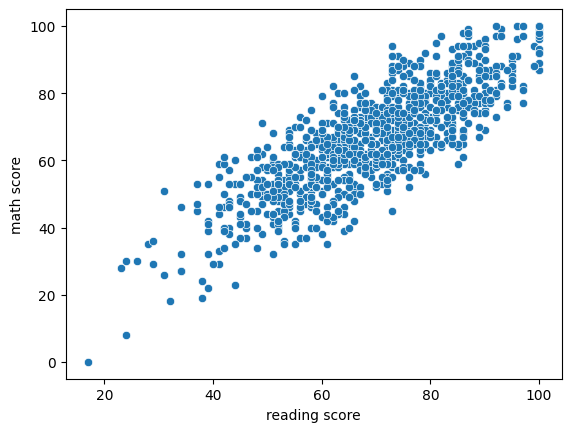

In [150]:
sns.scatterplot(
x="reading score",
y="math score",
data=df
)

plt.show()

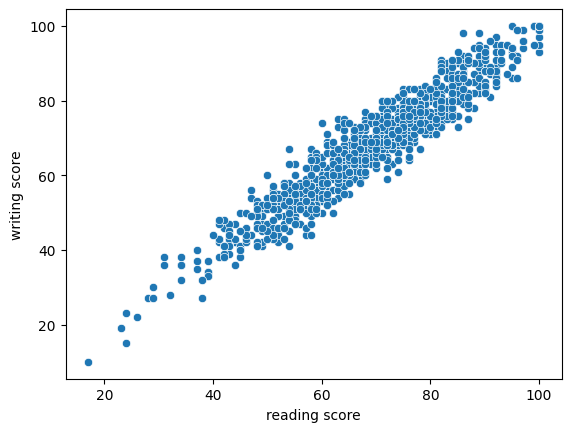

In [151]:
sns.scatterplot(
x="reading score",
y="writing score",
data=df
)

plt.show()

### Outlier Analysis

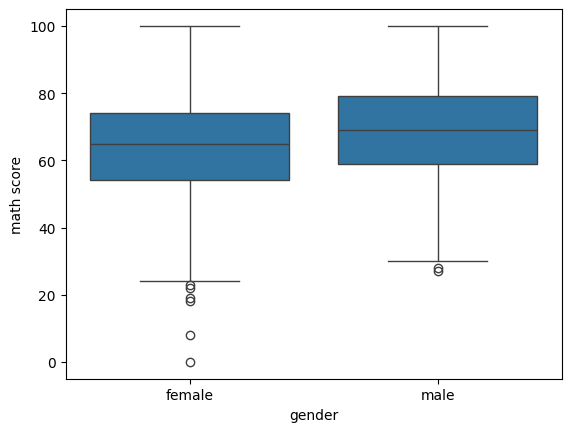

In [152]:
sns.boxplot(
x="gender",
y="math score",
data=df
)

plt.show()

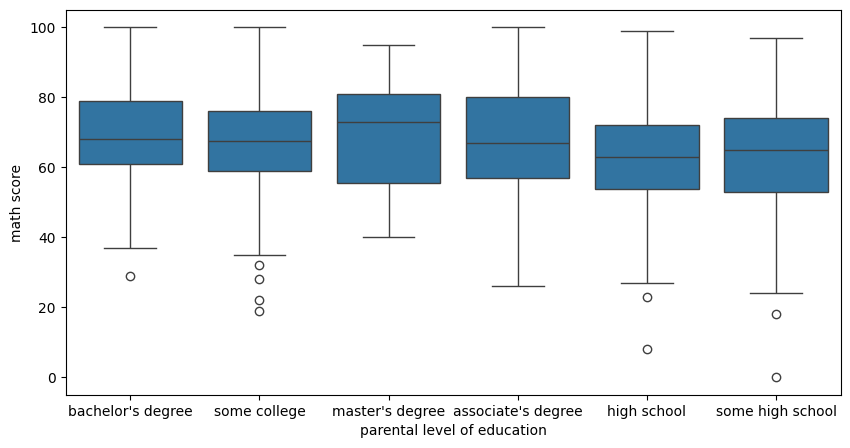

In [153]:
plt.figure(figsize=(10, 5))
sns.boxplot(
x="parental level of education",
y="math score",
data=df
)

plt.show()

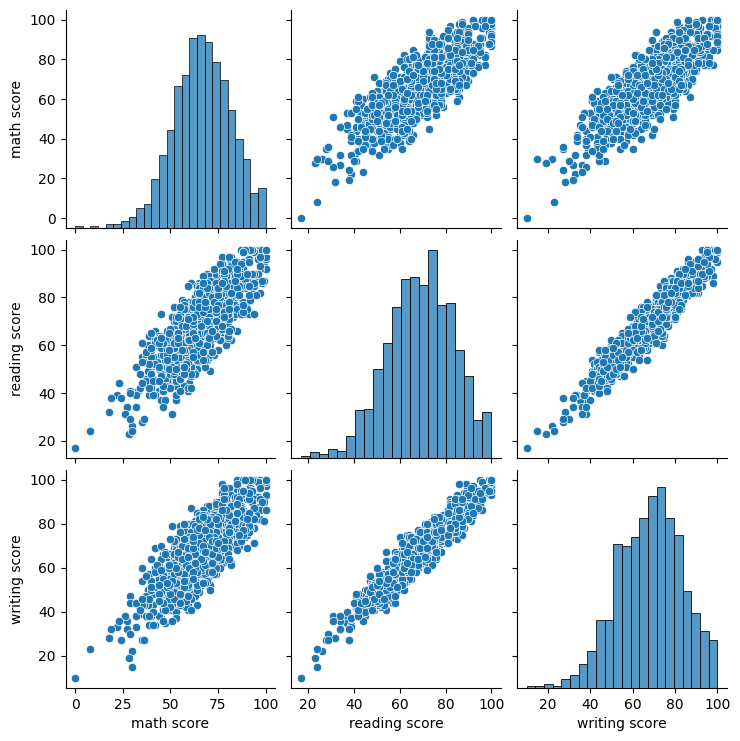

In [154]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
    df[['math score', 'reading score', 'writing score']],
    diag_kind='hist'
)

plt.show()

### Bivariate Analysis

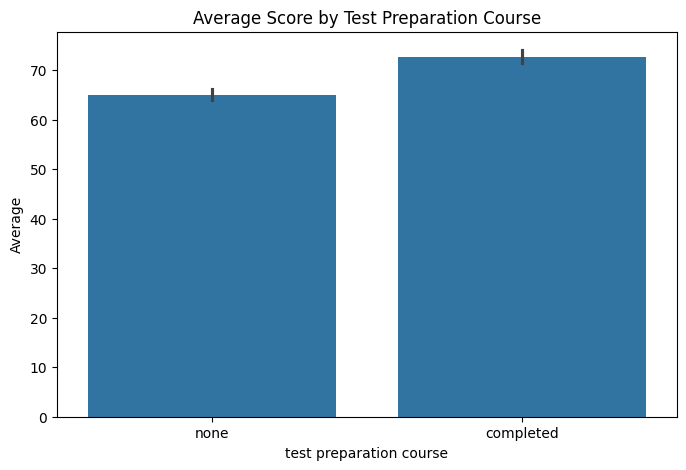

In [163]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='test preparation course',
    y='Average'
)

plt.title("Average Score by Test Preparation Course")
plt.show()

Interpretation

Students who completed the test preparation course generally achieved higher average scores than those who did not.

Average Score Comparison (Violin Plot)

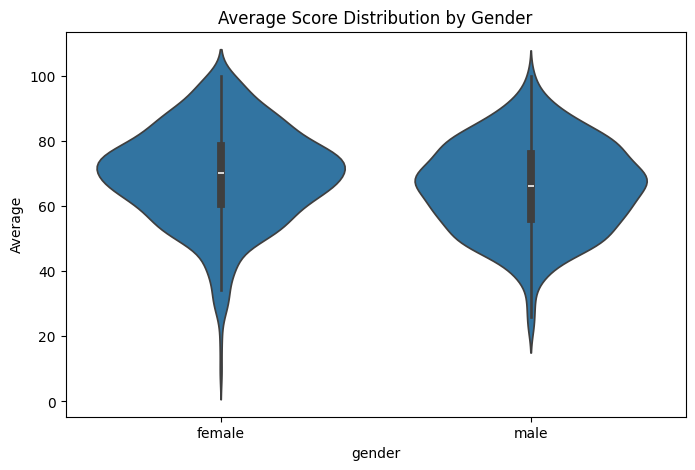

In [162]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x='gender',
    y='Average'
)

plt.title("Average Score Distribution by Gender")
plt.show()

Interpretation

The violin plot shows the distribution of average scores across genders, highlighting both the spread and concentration of scores

Detailed Outlier Analysis

In [161]:
numerical_cols = [
    'math score',
    'reading score',
    'writing score',
    'Average'
]

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}")
    print("Number of Outliers:", len(outliers))
    print("-"*40)

math score
Number of Outliers: 8
----------------------------------------
reading score
Number of Outliers: 6
----------------------------------------
writing score
Number of Outliers: 5
----------------------------------------
Average
Number of Outliers: 6
----------------------------------------


Interpretation

Only a small number of observations fall outside the normal range, indicating that the dataset contains few extreme values.

Average Score by Parent Education

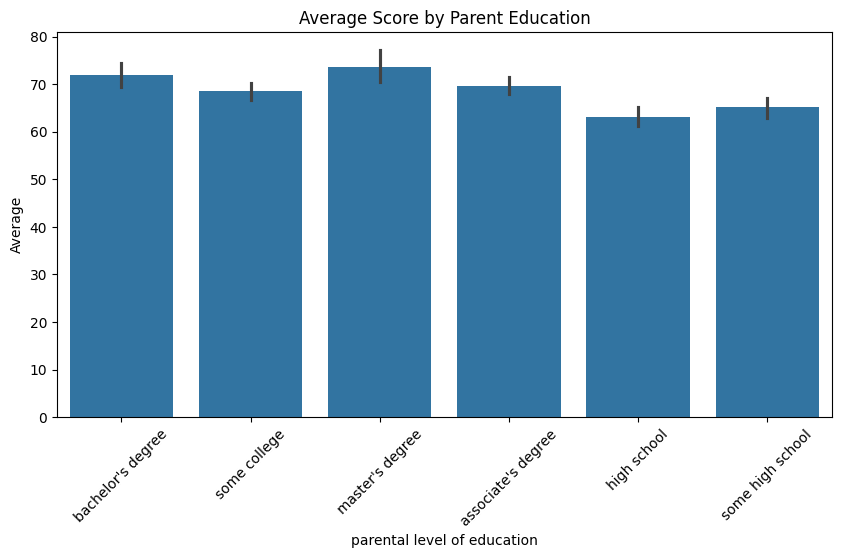

In [160]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x='parental level of education',
    y='Average'
)

plt.xticks(rotation=45)

plt.title("Average Score by Parent Education")

plt.show()

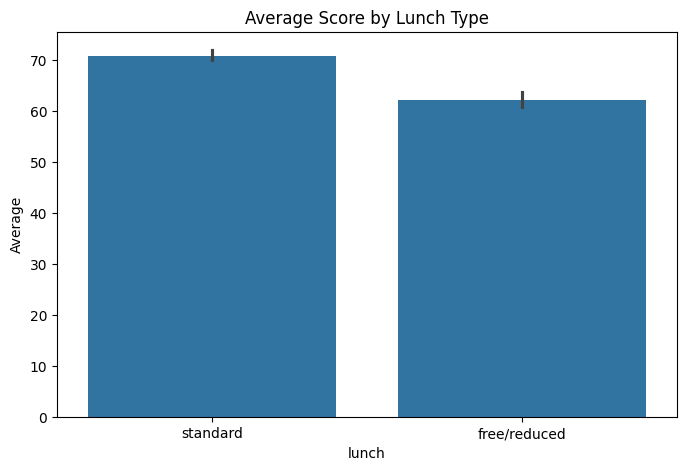

In [159]:
# Ensure 'Average' column is available
if 'Average' not in df.columns:
    df["Average"] = (df["math score"] + df["reading score"] + df["writing score"]) / 3

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='lunch',
    y='Average'
)

plt.title("Average Score by Lunch Type")
plt.show()

Interpretation

Students whose parents have higher educational qualifications tend to achieve slightly higher average scores.

### Correlation Analysis

In [164]:
corr = df.corr(numeric_only=True)
corr

,math score,reading score,writing score,Average
math score,1.000000,0.817580,0.802642,0.918746
reading score,0.817580,1.000000,0.954598,0.970331
writing score,0.802642,0.954598,1.000000,0.965667
Average,0.918746,0.970331,0.965667,1.000000


In [165]:
top = df.sort_values(
"math score",
ascending=False
)

top.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Average
962,female,group E,associate's degree,standard,none,100,100,100,100.000000
458,female,group E,bachelor's degree,standard,none,100,100,100,100.000000
149,male,group E,associate's degree,free/reduced,completed,100,100,93,97.666667
625,male,group D,some college,standard,completed,100,97,99,98.666667
916,male,group E,bachelor's degree,standard,completed,100,100,100,100.000000
451,female,group E,some college,standard,none,100,92,97,96.333333
623,male,group A,some college,standard,completed,100,96,86,94.000000
263,female,group E,high school,standard,none,99,93,90,94.000000
114,female,group E,bachelor's degree,standard,completed,99,100,100,99.666667
306,male,group E,some college,standard,completed,99,87,81,89.000000


In [166]:
low = df.sort_values(
"math score"
)

low.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Average
59,female,group C,some high school,free/reduced,none,0,17,10,9.000000
980,female,group B,high school,free/reduced,none,8,24,23,18.333333
17,female,group B,some high school,free/reduced,none,18,32,28,26.000000
787,female,group B,some college,standard,none,19,38,32,29.666667
145,female,group C,some college,free/reduced,none,22,39,33,31.333333
842,female,group B,high school,free/reduced,completed,23,44,36,34.333333
338,female,group B,some high school,free/reduced,none,24,38,27,29.666667
466,female,group D,associate's degree,free/reduced,none,26,31,38,31.666667
363,female,group D,some high school,free/reduced,none,27,34,32,31.000000
91,male,group C,high school,free/reduced,none,27,34,36,32.333333


In [167]:
df["math score"].mean()

np.float64(66.089)

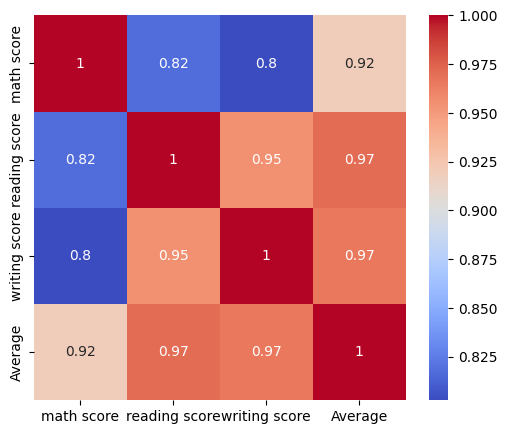

In [168]:
plt.figure(figsize=(6,5))

sns.heatmap(
    df[["math score", "reading score", "writing score", "Average"]].corr(),
    annot=True,
    cmap="coolwarm"
)


plt.show()

## Feature Engineering

In [169]:
df["Average"] = (
df["math score"] +
df["reading score"] +
df["writing score"]
)/3

In [170]:
df['FinalScore'] = df['math score'] + df['reading score'] + df['writing score']
df["FinalScore"].max()

300

In [171]:
df["FinalScore"].min()

27

In [172]:
def grade(x):

    if x>=90:
        return "A"

    elif x>=80:
        return "B"

    elif x>=70:
        return "C"

    elif x>=60:
        return "D"

    else:
        return "F"

df["Grade"] = df["Average"].apply(grade)
print(df["Grade"])

0      C
1      B
2      A
3      F
4      C
      ..
995    A
996    F
997    D
998    C
999    B
Name: Grade, Length: 1000, dtype: object


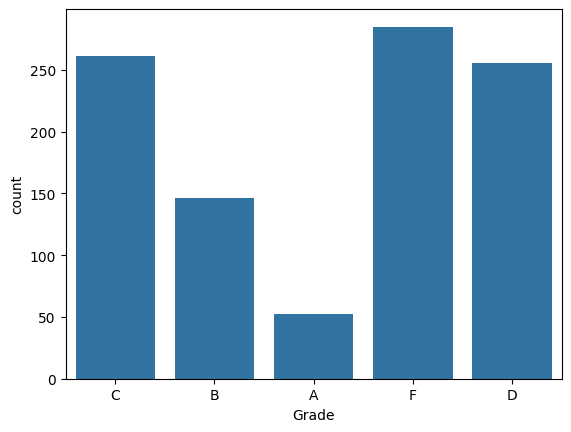

In [173]:
sns.countplot(
x="Grade",
data=df
)

plt.show()

• Most students scored between 50–80.

• Reading and Writing scores have a strong positive correlation.

• Students who completed the test preparation course generally scored higher.

• Standard lunch students achieved better average scores.

• Only a few outliers were detected.

• Overall data quality is good.

# ==========================================
# Machine Learning
# ==========================================

# Average Score Prediction using Linear Regression

##Import Libraries

In [174]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

##Feature Selection

In [175]:
X = df[['gender',
        'race/ethnicity',
        'parental level of education',
        'lunch',
        'test preparation course']]

y = df['Average']

##One Hot Encoding

In [176]:
X = pd.get_dummies(X, drop_first=True)

##Train test Split

In [177]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

##Train Model

In [178]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

##Prediction

In [179]:
y_pred = model.predict(X_test)

##Evaluation

In [180]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)

print("Mean Squared Error :", mse)

print("Root Mean Squared Error :", rmse)

print("R² Score :", r2)

Mean Absolute Error : 10.490182374209294
Mean Squared Error : 179.60234233623538
Root Mean Squared Error : 13.401579844788277
R² Score : 0.16217185763155217


##Actual vs Predicted Plot

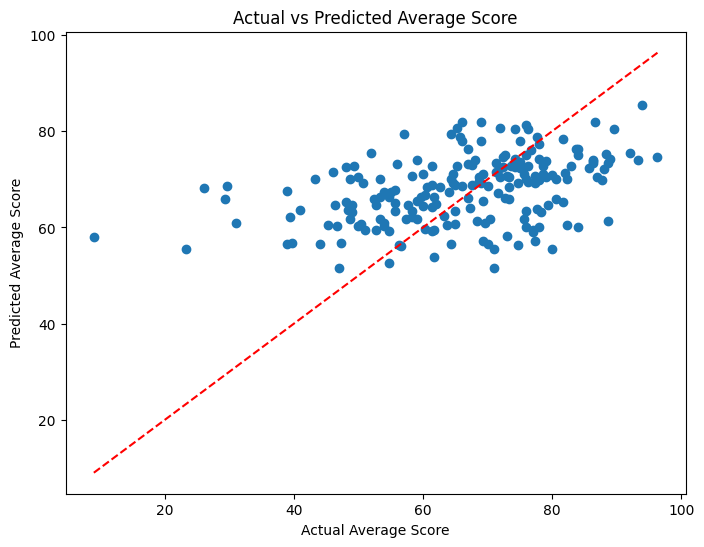

In [181]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Average Score")

plt.ylabel("Predicted Average Score")

plt.title("Actual vs Predicted Average Score")

plt.show()

##Prediction Table

In [182]:
prediction = pd.DataFrame({

    "Actual Score": y_test,

    "Predicted Score": y_pred

})

prediction.head(10)

,Actual Score,Predicted Score
521,87.000000,70.522773
737,64.000000,67.280948
740,75.000000,72.795942
660,74.666667,56.369159
411,81.666667,78.496790
678,78.000000,60.086185
626,67.333333,64.043195
513,59.000000,74.069709
859,77.333333,57.223262
136,48.666667,69.977854


##New Student Prediction

In [183]:
new_student = pd.DataFrame({

    'gender':['female'],

    'race/ethnicity':['group B'],

    'parental level of education':["bachelor's degree"],

    'lunch':['standard'],

    'test preparation course':['completed']

})

new_student = pd.get_dummies(new_student)

new_student = new_student.reindex(columns=X.columns, fill_value=0)

predicted_score = model.predict(new_student)

print("Predicted Average Score :", predicted_score[0])

Predicted Average Score : 80.84480704192764
